이 자료는 '위키독스 딥 러닝을 이용한 자연어 처리 입문, 네이버 영화 리뷰 튜토리얼입니다.'

링크 : https://wikidocs.net/44249

In [1]:
import tensorflow as tf
tf.__version__

'2.19.0'

In [2]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 116.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 42.7 MB/s eta 0:00:00


# 1. 네이버 영화 리뷰 데이터에 대한 이해와 전처리

In [3]:
# ============================================
# 🧠 한국어 텍스트 데이터 전처리 및 토큰화 준비
# ============================================

# 데이터 분석을 위한 라이브러리 (엑셀, CSV 등 표 형태 데이터를 다룸)
import pandas as pd

# 인터넷에서 파일(데이터셋)을 다운로드할 때 사용하는 라이브러리
import urllib.request

# 그래프 시각화를 위한 기본 라이브러리
import matplotlib.pyplot as plt

# 정규표현식(Regular Expression)
# 텍스트에서 특수문자, 숫자, 영어 등을 제거하거나 특정 패턴을 찾을 때 사용
import re

# 한국어 형태소 분석기: 단어 단위로 분리하고 품사 태깅 기능 제공
# Okt(Open Korea Text) → 과거 트위터 형태소 분석기 기반
from konlpy.tag import Okt

# tqdm : 반복문 실행 시 진행률(progress bar)을 시각적으로 표시
from tqdm import tqdm

# 텍스트를 숫자로 변환하는 Tokenizer (단어 인덱스 생성)
from tensorflow.keras.preprocessing.text import Tokenizer

# 수학적 계산 및 배열 처리를 위한 기본 라이브러리
import numpy as np

# pad_sequences() : 문장의 길이를 동일하게 맞춰주는 함수 (짧은 문장은 0으로 채움)
from tensorflow.keras.preprocessing.sequence import pad_sequences

| 항목          | 내용                                                                  |
| ----------- | ------------------------------------------------------------------- |
| **데이터셋 이름** | NSMC (Naver Sentiment Movie Corpus)                                 |
| **출처**      | GitHub - [https://github.com/e9t/nsmc](https://github.com/e9t/nsmc) |
| **파일 형식**   | `ratings_train.txt`, `ratings_test.txt` (탭 구분 텍스트 파일)               |
| **데이터 구성**  | 영화 리뷰(`document`)와 감정 레이블(`label`, 0=부정 / 1=긍정)                     |


In [4]:
# ============================================
# 🎬 네이버 영화 리뷰 데이터(NSMC) 다운로드
# ============================================

# urllib.request.urlretrieve(주소, 저장파일명)
# → 인터넷(URL)에서 파일을 다운로드하여 로컬(내 컴퓨터)에 저장하는 함수

# 1️⃣ 훈련용 데이터 다운로드
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    filename="ratings_train.txt"
)

# 2️⃣ 테스트용 데이터 다운로드
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
    filename="ratings_test.txt"
)

('ratings_test.txt', <http.client.HTTPMessage at 0x798814341b80>)

| id       | document                         | label |
| -------- | -------------------------------- | ----- |
| 9976970  | 아 더빙.. 진짜 짜증나네요 목소리              | 0     |
| 3819312  | 흠...포스터보고 초딩영화줄...오버연기조차 가볍지 않구나 | 1     |
| 10265843 | 너무재밌어요                           | 1     |


In [5]:
# ============================================
# 🎬 네이버 영화 리뷰 데이터 불러오기
# ============================================

# pd.read_table() :
#   - 탭(tab, \t)으로 구분된 텍스트 파일(.txt)을 읽어오는 함수
#   - 결과는 DataFrame(엑셀처럼 표 형태의 데이터)으로 반환됨

# 훈련 데이터 불러오기
train_data = pd.read_table('ratings_train.txt')

# 테스트 데이터 불러오기
test_data = pd.read_table('ratings_test.txt')

In [6]:
print('훈련 샘플의 개수 :',len(train_data)) # 훈련용 리뷰 개수 출력
print('테스트 샘플의 개수 :',len(test_data)) # 테스트용 리뷰 개수 출력

훈련 샘플의 개수 : 150000
테스트 샘플의 개수 : 50000


In [7]:
train_data[:5] # 상위 5개 출력

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [8]:
# ============================================
# 📊 훈련 데이터의 고유 리뷰 개수와 레이블 종류 수 확인
# ============================================

# nunique() :
#   - 고유한(중복되지 않은) 값의 개수를 반환하는 함수

# 1️⃣ 리뷰(document) 열의 고유 개수
#    → 중복된 리뷰가 몇 개 있는지 파악 가능
# 2️⃣ 레이블(label) 열의 고유 개수
#    → 감정 분류가 몇 가지인지(보통 0, 1 두 개)
train_data['document'].nunique(), train_data['label'].nunique()

(146182, 2)

In [9]:
# ============================================
# 🧹 중복 리뷰 제거 (데이터 정제 단계)
# ============================================

# drop_duplicates() :
#   - 지정한 열(subset)에서 중복된 행(리뷰)을 제거하는 함수
#   - inplace=True : 원본 데이터(train_data)에 바로 적용 (새 변수에 저장하지 않음)

train_data.drop_duplicates(subset=['document'], inplace=True)  # 'document' 열 기준으로 중복 리뷰 제거

In [10]:
print('총 샘플의 수 :',len(train_data))

총 샘플의 수 : 146183


<Axes: xlabel='label'>

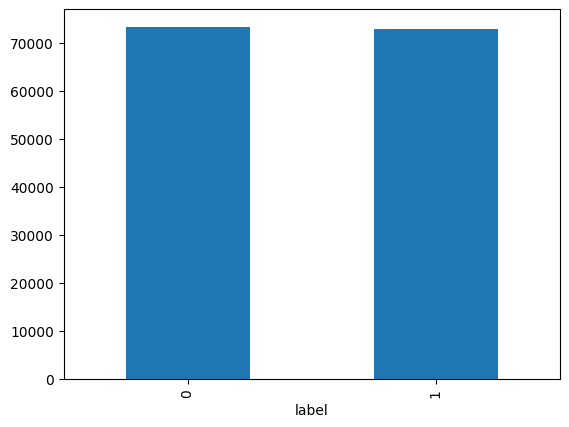

In [11]:
train_data['label'].value_counts().plot(kind = 'bar')

In [12]:
print(train_data.groupby('label').size().reset_index(name = 'count'))

   label  count
0      0  73342
1      1  72841


In [13]:
# ============================================
# 🔍 결측치(null, NaN) 존재 여부 확인
# ============================================

# isnull() :
#   각 셀(값)이 결측치인지(True/False) 판별
# values :
#   DataFrame을 numpy 배열 형태로 변환
# any() :
#   하나라도 True(결측치)가 있으면 True 반환

print(train_data.isnull().values.any())

True


In [14]:
# ============================================
# 📊 각 열(column)별 결측치(null) 개수 확인
# ============================================

# isnull() : 각 셀의 결측 여부를 True/False로 표시
# sum() : True를 1로 계산하여 각 열별로 합산
# → 즉, 각 열마다 결측치(빈 값)가 몇 개 있는지를 반환
print(train_data.isnull().sum())

id          0
document    1
label       0
dtype: int64


In [15]:
# ============================================
# 🔍 결측치가 포함된 행 직접 확인하기
# ============================================

# train_data.document.isnull() :
#   'document' 열에서 값이 비어 있는(NaN) 행을 True로 표시

# loc[] :
#   조건에 해당하는 행(row)만 선택하여 표시

# → 'document'가 결측치인 행만 추출하여 출력
train_data.loc[train_data.document.isnull()]

,id,document,label
25857,2172111,NaN,1


In [16]:
# ============================================
# 🧹 결측치(NaN) 제거 및 제거 결과 확인
# ============================================

# dropna() :
#   - 결측치가 포함된 행(row)을 삭제하는 함수
#   - how='any' → 하나라도 결측치가 있으면 해당 행 전체를 삭제
#   - inplace=True로 지정하면 원본 데이터에 바로 반영 가능
train_data = train_data.dropna(how='any')  # Null 값이 존재하는 행 제거

# 결측치가 남아 있는지 다시 확인
# isnull() : 결측치 여부 확인 (True/False)
# values.any() : 하나라도 True가 있으면 True 반환
print(train_data.isnull().values.any())  # → False면 모든 결측치가 제거된 것

False


In [17]:
print(len(train_data))

146182


| 패턴         | 의미                 |
| ---------- | ------------------ |
| `[^ ]`     | 대괄호 안의 문자를 제외한 나머지 |
| `ㄱ-ㅎ`      | 한글 자음 범위           |
| `ㅏ-ㅣ`      | 한글 모음 범위           |
| `가-힣`      | 완성형 한글(가~힣) 범위     |
| `' '` (공백) | 단어 간 띄어쓰기를 유지하기 위함 |


In [18]:
# ============================================
# 🧹 텍스트 정제 (불필요한 문자 제거)
# ============================================

# 정규표현식(Regular Expression, regex)을 이용하여 한글과 공백만 남김
# [^ㄱ-ㅎㅏ-ㅣ가-힣 ] :
#   ㄱ~ㅎ : 자음, ㅏ~ㅣ : 모음, 가~힣 : 완성형 한글
#   ^ : 대괄호 안의 문자를 제외한 모든 문자 선택
# 즉, 한글과 공백을 제외한 모든 문자를 제거

train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)

# 정제된 데이터의 상위 5개 행 확인
train_data[:5]

,id,document,label
0,9976970,아 더빙 진짜 짜증나네요 목소리,0
1,3819312,흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 솔직히 재미는 없다평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...,1


In [19]:
# ============================================
# ⚙️ 공백(빈 문자열) 데이터 제거 처리
# ============================================

# 1️⃣ 정규표현식을 이용해 문장 앞뒤의 불필요한 공백 제거
# '^ +' : 문자열의 시작(^) 부분에 있는 하나 이상의 공백을 의미
# 공백만 남은 데이터를 '' (빈 문자열)로 변환
train_data['document'] = train_data['document'].str.replace('^ +', "", regex=True)

# 2️⃣ 공백("") 문자열을 NaN으로 변경
# 정제 후 완전히 비어 있는 리뷰는 NaN 값으로 변환하여 결측치로 처리
train_data['document'].replace('', np.nan, inplace=True)

# 3️⃣ 결측치가 존재하는지 다시 확인
print(train_data.isnull().sum())

id            0
document    789
label         0
dtype: int64


/tmp/ipython-input-2873060105.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['document'].replace('', np.nan, inplace=True)


In [20]:
# ============================================
# 🔍 정제 후 비어 있는(NaN) 리뷰 데이터 확인
# ============================================

# train_data.document.isnull() :
#   'document' 열에서 값이 NaN(결측치)인 행을 True로 표시

# loc[] :
#   조건(True인 행)에 해당하는 데이터를 선택

# [:5] :
#   결측치가 있는 상위 5개 행만 출력
train_data.loc[train_data.document.isnull()][:5]

,id,document,label
404,4221289,NaN,0
412,9509970,NaN,1
470,10147571,NaN,1
584,7117896,NaN,0
593,6478189,NaN,0


In [21]:
# ============================================
# 🧹 결측치(NaN) 리뷰 제거
# ============================================

# dropna() :
#   결측치(Null, NaN)가 포함된 행(row)을 삭제하는 함수
#   how='any' → 한 행에 하나라도 결측치가 있으면 그 행 전체 삭제
#   inplace=True로 설정하면 원본 데이터에 바로 적용 가능

train_data = train_data.dropna(how='any')  # 결측치가 있는 리뷰 제거

In [22]:
print(len(train_data))

145393


In [23]:
# ============================================
# 🧹 테스트 데이터(test_data) 전처리 과정
# ============================================

# 1️⃣ 중복 리뷰 제거
# 'document' 열에서 동일한 문장이 여러 번 등장하면 하나만 남김
test_data.drop_duplicates(subset=['document'], inplace=True)

# 2️⃣ 정규표현식으로 한글과 공백만 남기기
# 한글(가~힣)과 공백을 제외한 모든 문자(영어, 숫자, 특수기호 등) 제거
test_data['document'] = test_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)

# 3️⃣ 불필요한 공백 제거
# 문장 맨 앞에 있는 연속된 공백(‘   ’ 등)을 제거
test_data['document'] = test_data['document'].str.replace('^ +', "", regex=True)

# 4️⃣ 공백만 남은 행을 NaN(결측치)로 변경
# 예: "ㅋㅋㅋㅋ" → "" → NaN
test_data['document'].replace('', np.nan, inplace=True)

# 5️⃣ 결측치가 포함된 행 제거
# 내용이 완전히 사라진 리뷰를 삭제
test_data = test_data.dropna(how='any')

# 6️⃣ 전처리 완료 후 남은 샘플 개수 확인
print('전처리 후 테스트용 샘플의 개수 :', len(test_data))

전처리 후 테스트용 샘플의 개수 : 48852


/tmp/ipython-input-4189293520.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['document'].replace('', np.nan, inplace=True)


In [24]:
print('전처리 후 테스트용 샘플의 개수 :',len(test_data))

전처리 후 테스트용 샘플의 개수 : 48852


In [25]:
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

### Kiwipiepy 형태소분석기

| 항목            | 내용                                                  |
| ------------- | --------------------------------------------------- |
| **이름**        | Kiwipiepy (키위파이파이)                                  |
| **개발자 / 배포처** | Kakao Enterprise                                    |
| **언어**        | Python용 한국어 형태소 분석기                                 |
| **설명**        | 카카오의 형태소 분석 엔진 “Kiwi”를 Python에서 사용할 수 있도록 포팅한 라이브러리 |
| **설치 명령어**    | `pip install kiwipiepy`                             |



| 구분                       | 설명                                               |
| ------------------------ | ------------------------------------------------ |
| ✅ **빠른 속도**              | C++ 기반 분석 엔진으로, Python 래퍼를 통해 **Okt보다 5~10배 빠름** |
| ✅ **정확한 형태소 분석**         | 신조어·복합명사 인식, 띄어쓰기 오류 보정 기능 포함                    |
| ✅ **메모리 효율성**            | 대용량 텍스트(수십만 문장)도 안정적으로 처리 가능                     |
| ✅ **품사 태깅(POS Tagging)** | 세밀한 품사 정보 제공 (예: 체언, 용언, 조사, 어미 등)               |
| ✅ **사용자 사전 추가 가능**       | `add_user_word()`로 분석 성능 조정 가능                   |
| ✅ **병렬 처리 지원**           | `analyze_parallel()` 등으로 멀티코어 활용 가능              |


| 메서드                                   | 설명                  | 예시                                        |
| ------------------------------------- | ------------------- | ----------------------------------------- |
| `tokenize(text)`                      | 입력 문장을 형태소 단위로 분할   | `[Token(form='영화', tag='NNG'), ...]`      |
| `analyze(text)`                       | 형태소, 품사, 확률 등 세부 분석 | 여러 분석 후보 중 확률 높은 결과 반환                    |
| `add_user_word(word, tag, score=0.0)` | 사용자 정의 단어 추가        | `kiwi.add_user_word('딥러닝', 'NNG')`        |
| `join(tokens)`                        | 형태소 리스트를 문장으로 재조합   | `[('너무', 'MAG'), ('좋다', 'VA')] → '너무 좋다'` |
| `analyze_parallel()`                  | 여러 문장을 병렬로 처리       | 대용량 데이터 분석 시 빠름                           |


In [27]:
%pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 65.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 17.4 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.21.0-py3-none-any.whl size=35593192 sha256=89b2ae3791ccaa276af9770a8afc66dbaf1e642605b544871f843fe1e77dd93b
  Stored in directory: /root/.cache/pip/wheels/5f/94/81/3e8b1478625f1bdb3b72733dfe3086a8f77a8f25db2b1d746b
Successfully built kiwipiepy_model


In [ ]:
from kiwipiepy import Kiwi
kiwi = Kiwi()

# 형태소 분석 (Morphological Analysis)
sentence = "너무 재미있는 영화였어요!"
tokens = kiwi.tokenize(sentence)

for token in tokens:
    print(token.form, token.tag)

In [28]:
# ============================================
# 🧠 Kiwipiepy 형태소 분석기를 이용한 학습 데이터 전처리
# ============================================

# 형태소 분석기 불러오기
from kiwipiepy import Kiwi
kiwi = Kiwi()

# 학습데이터 형태소 분석에 약 2분 정도 소요
X_train = []

# tqdm : 진행률(progress bar)을 표시해줌
for sentence in tqdm(train_data['document']):

    # 1️⃣ 형태소 분석 수행
    # analyze() → 형태소, 품사, 시작위치, 끝위치 등의 정보 반환
    # 여기서는 형태소만 추출하기 위해 리스트 내포로 word만 가져옴
    tokenized_sentence = [token.form for token in kiwi.tokenize(sentence)]

    # 2️⃣ 불용어(stopwords) 제거
    # stopwords 목록에 포함되지 않은 단어만 남김
    stopwords_removed_sentence = [
        word for word in tokenized_sentence if word not in stopwords
    ]

    # 3️⃣ 전처리된 문장을 리스트에 추가
    X_train.append(stopwords_removed_sentence)

100%|██████████| 145393/145393 [02:24<00:00, 1007.14it/s]


In [29]:
# ============================================
# 🧠 Kiwipiepy 형태소 분석기를 이용한 테스트 데이터 전처리
# ============================================

from kiwipiepy import Kiwi
kiwi = Kiwi()

# 테스트 데이터 형태소 분석에 약 3분 정도 소요
X_test = []

# tqdm : 진행 상황을 시각적으로 표시해주는 progress bar
for sentence in tqdm(test_data['document']):

    # 1️⃣ 형태소 분석 (토큰화)
    # tokenize()는 형태소 객체(Token)를 반환하므로
    # 각 형태소의 문자열만 추출 (token.form)
    tokenized_sentence = [token.form for token in kiwi.tokenize(sentence)]

    # 2️⃣ 불용어 제거
    # stopwords 목록에 포함되지 않은 단어만 남김
    stopwords_removed_sentence = [
        word for word in tokenized_sentence if word not in stopwords
    ]

    # 3️⃣ 최종 전처리된 문장을 리스트에 추가
    X_test.append(stopwords_removed_sentence)

100%|██████████| 48852/48852 [00:45<00:00, 1067.44it/s]


In [30]:
print('전처리 후 테스트용 샘플의 개수 :',len(X_test))

전처리 후 테스트용 샘플의 개수 : 48852


In [31]:
# ============================================
# 🔢 텍스트 데이터를 숫자(정수)로 변환하기 위한 Tokenizer 설정
# ============================================

from tensorflow.keras.preprocessing.text import Tokenizer

# 1️⃣ Tokenizer 객체 생성
# Tokenizer는 단어(형태소)에 고유 번호(index)를 부여하는 도구
tokenizer = Tokenizer()

# 2️⃣ 학습 데이터(X_train)에 등장한 모든 단어를 기준으로 단어 사전(vocabulary) 구축
#   - fit_on_texts() : 리스트 형태의 문장 데이터를 입력받아 단어 빈도 계산
#   - 단어별 등장 횟수를 세고, 자주 등장한 단어일수록 낮은 번호(index)를 부여
tokenizer.fit_on_texts(X_train)

In [32]:
print(tokenizer.word_index)

{'하': 1, 'ᆫ': 2, '영화': 3, '었': 4, '다': 5, '보': 6, '고': 7, '어': 8, '을': 9, 'ᆯ': 10, '지': 11, '나': 12, '게': 13, '있': 14, '없': 15, '거': 16, 'ᆷ': 17, '것': 18, '되': 19, '어서': 20, '좋': 21, '만': 22, '주': 23, '는데': 24, '너무': 25, '음': 26, '기': 27, '안': 28, '적': 29, '어요': 30, '정말': 31, '로': 32, 'ᆫ다': 33, '말': 34, '재밌': 35, '네요': 36, '같': 37, '지만': 38, '에서': 39, '점': 40, '진짜': 41, '않': 42, '아니': 43, '네': 44, '수': 45, '만들': 46, '면': 47, '연기': 48, '나오': 49, 'ᆸ니다': 50, '최고': 51, '뭐': 52, '평점': 53, '던': 54, '이런': 55, '이거': 56, '겠': 57, '왜': 58, '생각': 59, '습니다': 60, '그': 61, '스토리': 62, '듯': 63, '어도': 64, '때': 65, '드라마': 66, '싶': 67, '사람': 68, '배우': 69, '감동': 70, '더': 71, '보다': 72, '까지': 73, 'ᆫ데': 74, '아깝': 75, '알': 76, 'ㅋㅋ': 77, '내용': 78, '감독': 79, '재미': 80, '그냥': 81, 'ᆫ가': 82, '못': 83, '시': 84, '중': 85, '시간': 86, '어야': 87, '재미있': 88, 'ᆫ지': 89, '라': 90, '쓰레기': 91, '사랑': 92, '냐': 93, '아': 94, '재미없': 95, '라고': 96, '모르': 97, '오': 98, '다시': 99, '면서': 100, '번': 101, '보이': 102, '저': 103, '니': 104, '작품': 105

In [33]:
print(tokenizer.word_counts.items())

odict_items([('아', 3317), ('더빙', 530), ('진짜', 8328), ('짜증', 1491), ('나', 22189), ('네요', 8736), ('목소리', 373), ('흠', 230), ('포스터', 559), ('보', 52840), ('고', 47416), ('초딩', 413), ('영화', 58148), ('줄', 2368), ('오버', 128), ('연기', 7341), ('조차', 314), ('가볍', 363), ('지', 23175), ('않', 7894), ('구나', 845), ('너무재밓', 1), ('었', 56194), ('다', 55548), ('그래서', 456), ('것', 14375), ('을', 30572), ('추천', 1184), ('하', 97401), ('ᆫ다', 9280), ('교도소', 14), ('이야기', 2205), ('구먼', 41), ('솔직히', 1082), ('재미', 4081), ('없', 15939), ('평점', 6214), ('조정', 45), ('사이몬페그', 2), ('익살', 11), ('스럽', 2509), ('ᆫ', 77010), ('돋보이', 291), ('던', 6019), ('스파이더맨', 56), ('에서', 8390), ('늙', 199), ('어', 39570), ('보이', 3033), ('기', 10351), ('만', 11828), ('커스틴 던스트', 5), ('너무나', 702), ('이쁘', 999), ('막', 493), ('걸음마', 2), ('떼', 165), ('세', 1200), ('부터', 2000), ('초등학교', 107), ('학년', 142), ('생', 566), ('살', 2033), ('용', 1210), ('ㅋㅋㅋ', 2448), ('별반', 79), ('개', 2695), ('아깝', 4407), ('음', 10601), ('원작', 1326), ('긴장감', 817), ('제대로', 818), ('살리', 52

In [34]:
# ============================================
# 📊 희귀 단어(rare words) 통계 확인
# ============================================

# threshold : '희귀 단어'를 판단하는 기준 빈도 (예: 3 미만으로 등장하면 희귀 단어로 간주)
threshold = 3

# 전체 단어 수 (Tokenizer가 생성한 단어 사전 크기)
total_cnt = len(tokenizer.word_index)

# 희귀 단어 수, 전체 등장 빈도, 희귀 단어 등장 빈도 초기화
rare_cnt = 0
total_freq = 0
rare_freq = 0

# Tokenizer.word_counts : {단어: 등장 빈도} 형태의 딕셔너리
for key, value in tokenizer.word_counts.items():
    total_freq += value  # 전체 단어 등장 횟수 누적

    # 단어의 등장 빈도가 기준(threshold)보다 작을 경우
    if value < threshold:
        rare_cnt += 1           # 희귀 단어 개수 증가
        rare_freq += value      # 희귀 단어 등장 빈도 누적

# 결과 출력
print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s' % (threshold - 1, rare_cnt))
print("단어 집합에서 희귀 단어의 비율: {:.2f}%".format((rare_cnt / total_cnt) * 100))
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율: {:.2f}%".format((rare_freq / total_freq) * 100))

단어 집합(vocabulary)의 크기 : 45674
등장 빈도가 2번 이하인 희귀 단어의 수: 28063
단어 집합에서 희귀 단어의 비율: 61.44%
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 1.51%


In [35]:
vocab_size = total_cnt - rare_cnt + 1
print('단어 집합의 크기 :',vocab_size)

단어 집합의 크기 : 17612


In [36]:
# ============================================
# 🔢 희귀 단어 제거 후 정수 인코딩 (Integer Encoding)
# ============================================

# 1️⃣ Tokenizer 객체 재생성
# num_words=vocab_size : 가장 자주 등장하는 단어만 사용
# (희귀 단어는 제외됨)
tokenizer = Tokenizer(num_words=vocab_size)  # 희귀 단어 제거

# 2️⃣ 학습 데이터로 단어 사전(vocabulary) 다시 구축
# X_train은 형태소 분석 + 불용어 제거가 완료된 리스트 형태의 데이터
tokenizer.fit_on_texts(X_train)

# 3️⃣ 학습 데이터 정수 인코딩
# 각 문장(형태소 리스트)을 단어의 고유번호 시퀀스로 변환
X_train = tokenizer.texts_to_sequences(X_train)

# 4️⃣ 테스트 데이터 정수 인코딩 (동일한 Tokenizer 사용)
# train과 같은 인덱스를 기준으로 변환해야 일관성 유지
X_test = tokenizer.texts_to_sequences(X_test)

In [37]:
# ============================================
# 🏷️ 감성 레이블(label)을 NumPy 배열로 변환
# ============================================

# train_data['label']과 test_data['label']은
# 각각 훈련용과 테스트용 데이터의 감정 레이블 (0=부정, 1=긍정)

# np.array() : 리스트나 판다스 Series를 넘파이 배열로 변환
# → 신경망 모델의 입력/출력 형태와 호환되도록 하기 위함
y_train = np.array(train_data['label'])
y_test = np.array(test_data['label'])

In [38]:
print(len(X_train))
print(len(y_train))

145393
145393


In [39]:
print(X_train[:3])

[[94, 493, 41, 210, 12, 36, 652], [940, 475, 6, 7, 609, 3, 138, 1445, 48, 746, 668, 11, 42, 331], [4, 5, 572, 6, 18, 9, 247, 1, 33]]


In [40]:
# ============================================
# ⚠️ 단어가 하나도 없는 문장(빈 시퀀스) 찾기
# ============================================

# enumerate() : 인덱스(index)와 문장(sentence)을 동시에 반복
# len(sentence) < 1 → 토큰화 결과가 비어 있는 경우 (예: 불용어만 있던 문장)

# 1️⃣ 학습 데이터에서 빈 문장 인덱스 수집
drop_train = [index for index, sentence in enumerate(X_train) if len(sentence) < 1]

# 2️⃣ 테스트 데이터에서도 동일하게 확인
drop_test = [index for index, sentence in enumerate(X_test) if len(sentence) < 1]

In [41]:
print(drop_train)

[522, 688, 727, 748, 792, 797, 899, 1040, 1399, 1572, 1982, 2321, 2521, 3111, 3129, 3181, 3393, 3563, 5256, 5298, 5415, 5722, 6548, 6660, 6689, 7103, 7137, 7149, 7273, 7421, 7540, 7790, 7873, 8032, 8376, 8421, 8441, 8853, 9019, 9076, 9660, 9817, 10121, 10372, 10596, 10783, 10823, 11016, 11341, 11669, 11897, 12002, 12111, 12535, 12766, 12861, 12999, 13583, 13747, 13788, 14035, 14561, 14843, 15427, 15721, 16011, 16316, 16407, 16509, 16807, 16908, 16937, 17080, 17243, 17351, 17586, 17816, 18423, 18615, 19224, 19286, 19364, 19722, 19739, 19775, 20011, 20077, 20723, 20764, 21297, 21821, 22101, 22297, 22583, 22594, 22667, 22805, 22917, 23400, 23998, 24338, 24351, 25031, 25943, 26313, 26768, 27110, 27175, 27540, 28136, 28438, 28462, 28474, 28600, 29272, 29287, 29618, 29878, 30076, 30187, 30363, 30623, 30799, 30817, 32031, 32452, 32454, 32551, 32874, 32926, 33161, 33915, 34017, 34407, 34594, 34919, 35226, 35388, 35791, 35820, 36295, 36325, 37099, 37260, 37481, 37716, 37728, 38422, 38826, 39525

In [42]:
len(drop_train)

565

In [43]:
# ============================================
# 🧹 빈 문장(단어가 없는 시퀀스) 제거
# ============================================

import numpy as np

# 1️⃣ NumPy 배열로 변환
# 문장마다 단어 개수가 다르므로 일반적인 2D 배열이 아니라
# dtype=object 형태로 지정해야 에러 없이 처리 가능
X_train = np.array(X_train, dtype=object)

# 2️⃣ 앞서 찾은 drop_train 인덱스를 기준으로
# 단어가 하나도 없는 문장을 삭제
X_train = np.delete(X_train, drop_train, axis=0)

# 3️⃣ 레이블(y_train)에서도 동일한 인덱스를 삭제해야
# 입력(X)과 출력(y)의 개수가 일치함
y_train = np.delete(y_train, drop_train, axis=0)

In [44]:
print(len(X_train))
print(len(y_train))

144828
144828


In [45]:
print(len(X_test))
print(len(y_test))

48852
48852


In [46]:
# ============================================
# 🧹 테스트 데이터에서 빈 문장(단어가 없는 시퀀스) 제거
# ============================================

# 1️⃣ NumPy 배열로 변환
# 문장마다 길이가 다르므로 dtype=object 형태로 지정해야 함
X_test = np.array(X_test, dtype=object)

# 2️⃣ 앞서 찾은 drop_test 인덱스를 기준으로
# 단어가 하나도 없는 문장을 삭제
X_test = np.delete(X_test, drop_test, axis=0)

In [47]:
# ============================================
# 🧩 X_test에서 삭제한 인덱스에 맞춰 y_test도 동일하게 삭제
# ============================================

# np.delete() :
#  - 지정한 인덱스(drop_test)에 해당하는 원소를 삭제
#  - axis=0 : 행 단위로 삭제

# X_test에서 빈 문장을 제거했기 때문에,
# y_test에서도 같은 인덱스(정답 레이블)를 삭제해야
# 입력과 출력 데이터의 개수가 동일해짐
y_test = np.delete(y_test, drop_test, axis=0)

In [48]:
print(len(X_test))
print(len(y_test))

48630
48630


리뷰의 최대 길이 : 93
리뷰의 평균 길이 : 15.131576766923523


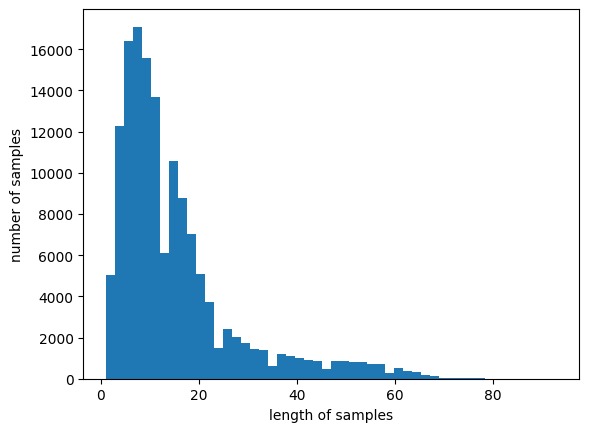

In [49]:
print('리뷰의 최대 길이 :',max(len(l) for l in X_train))
print('리뷰의 평균 길이 :',sum(map(len, X_train))/len(X_train))
plt.hist([len(s) for s in X_train], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [50]:
# ============================================
# 📏 문장 길이 비율 확인 함수
# ============================================

def below_threshold_len(max_len, nested_list):
    """
    전체 문장 중에서 길이가 max_len 이하인 문장의 비율을 계산하는 함수

    Parameters:
        max_len (int): 기준이 되는 최대 문장 길이
        nested_list (list): 각 문장을 토큰(단어 리스트)으로 가진 리스트 (예: X_train)
    """

    cnt = 0  # 조건을 만족하는 문장 수 카운트

    # 전체 문장을 순회하며 길이 확인
    for s in nested_list:
        if len(s) <= max_len:
            cnt += 1

    # 전체 대비 비율 계산 및 출력
    print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %.2f%%' %
          (max_len, (cnt / len(nested_list)) * 100))

In [51]:
max_len = 30
below_threshold_len(max_len, X_train)

전체 샘플 중 길이가 30 이하인 샘플의 비율: 89.08%


In [52]:
# ============================================
# 🧱 문장 길이 통일 (패딩, Padding)
# ============================================

# 전체 문장의 길이를 동일하게 맞춤
# max_len : 패딩 후 문장의 고정 길이 (예: 30)
# pad_sequences() :
#   - 각 문장을 동일한 길이의 시퀀스로 변환
#   - 짧은 문장은 앞쪽에 0을 채움 (pre-padding)
#   - 너무 긴 문장은 뒤쪽을 자름 (post-truncating)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# 2. LSTM으로 네이버 영화 리뷰 감성 분류하기

In [53]:
# ============================================
# 🧠 LSTM 기반 텍스트 분류 모델 구현에 필요한 Keras 모듈
# ============================================

# 신경망 층(Layer)
# - Embedding: 단어 ID → 의미 벡터로 변환 (입력층 역할)
# - LSTM: 순서를 가진 텍스트의 문맥을 학습 (순환 은닉층)
# - Dense: 완전연결층(출력층/중간층) — 분류 결과 계산
from tensorflow.keras.layers import Embedding, Dense, LSTM

# 모델 생성 도구
# - Sequential: 층을 순서대로 쌓는 가장 단순한 모델 구조
from tensorflow.keras.models import Sequential

# 저장/로드
# - load_model: 학습해 저장해 둔 모델(.keras/.h5)을 다시 불러오기
from tensorflow.keras.models import load_model

# 학습 보조 콜백
# - EarlyStopping: 검증 성능이 더 좋아지지 않으면 학습을 조기 종료(과적합 방지)
# - ModelCheckpoint: 학습 중 가장 성능 좋은 모델을 자동 저장
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

| 콜백 이름               | 역할       | 기준 지표      | 조건                 |
| ------------------- | -------- | ---------- | ------------------ |
| **EarlyStopping**   | 학습 조기 종료 | `val_loss` | 손실이 더 이상 감소하지 않을 때 |
| **ModelCheckpoint** | 최적 모델 저장 | `val_acc`  | 정확도가 최고일 때         |


In [54]:
# ============================================
# 🧩 학습 조기 종료 및 최적 모델 저장 설정
# ============================================

# 1️⃣ EarlyStopping : 조기 종료(Early Stopping)
# - 검증 데이터의 손실(val_loss)을 계속 모니터링하다가,
#   일정 횟수(patience) 이상 개선되지 않으면 학습을 자동으로 멈춤.
# - 과적합(overfitting)을 방지하는 대표적인 방법.
es = EarlyStopping(
    monitor='val_loss',   # 기준 지표: 검증 손실
    mode='min',           # 손실이 작을수록 성능이 좋다고 판단
    verbose=1,            # 진행 메시지 출력
    patience=4            # 4 epoch 연속 개선되지 않으면 학습 중단
)

# 2️⃣ ModelCheckpoint : 최적 모델 저장
# - 학습 도중 가장 성능이 좋은 모델(여기서는 val_acc 기준)을 자동 저장
# - 추후 평가나 예측 시 'best_model.keras' 파일을 다시 불러와 사용 가능
mc = ModelCheckpoint(
    'best_model.keras',   # 저장 파일 이름
    monitor='val_acc',    # 기준 지표: 검증 정확도
    mode='max',           # 정확도가 높을수록 좋은 모델로 판단
    verbose=1,            # 저장 시 로그 메시지 출력
    save_best_only=True   # 가장 좋은 모델만 저장 (중복 저장 방지)
)

| 층 이름                  | 입력/출력 형태                                     | 역할                    |
| --------------------- | -------------------------------------------- | --------------------- |
| **Embedding**         | (batch_size, 문장길이) → (batch_size, 문장길이, 100) | 단어 ID를 의미 벡터로 변환      |
| **LSTM(128)**         | (문장길이, 100) → (128)                          | 문맥과 순서 학습 (기억/망각 게이트) |
| **Dense(1, sigmoid)** | (128) → (1)                                  | 긍정/부정 확률 출력           |


In [55]:
# ============================================
# 🧠 LSTM 기반 감성 분석(이진 분류) 모델 구성
# ============================================

# Sequential : 층을 순서대로 쌓는 가장 단순한 모델 구조
model = Sequential()

# 1️⃣ Embedding 층
# - 입력: 단어의 고유번호(index)
# - 출력: 단어를 100차원 의미 벡터로 변환
# - vocab_size : 단어 집합의 크기
# - 100 : 각 단어를 표현할 벡터의 차원 수 (embedding_dim)
model.add(Embedding(vocab_size, 100))

# 2️⃣ LSTM 층
# - 128개의 메모리 셀(hidden units)을 가진 LSTM 층
# - 문장의 순서와 문맥(Context)을 학습
model.add(LSTM(128))

# 3️⃣ 출력층(Dense)
# - 노드 수 1개 → 긍정(1) / 부정(0) 예측
# - sigmoid 활성화 함수 → 출력값을 0~1 사이 확률로 변환
model.add(Dense(1, activation='sigmoid'))


In [ ]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train, y_train, epochs=15, callbacks=[es, mc], batch_size=64, validation_split=0.2)

Epoch 1/15
1824/1824 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.7655 - loss: 0.4728
Epoch 1: val_acc improved from -inf to 0.84166, saving model to best_model.keras
1824/1824 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - acc: 0.7655 - loss: 0.4727 - val_acc: 0.8417 - val_loss: 0.3624
Epoch 2/15
1822/1824 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8555 - loss: 0.3385
Epoch 2: val_acc improved from 0.84166 to 0.85269, saving model to best_model.keras
1824/1824 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - acc: 0.8555 - loss: 0.3384 - val_acc: 0.8527 - val_loss: 0.3420
Epoch 3/15
1823/1824 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8698 - loss: 0.3100
Epoch 3: val_acc improved from 0.85269 to 0.85848, saving model to best_model.keras
1824/1824 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.8698 - loss: 0.3100 - val_acc: 0.8585 - val_loss: 0.3282
Epoch 4/15
1823/1824 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8844 - loss: 0.2818
Epoch 4: val_acc improved from 0.85848 to 0.86119, saving model to best_model.keras
1824/

In [ ]:
loaded_model = load_model('best_model.keras')

In [ ]:
print("\n 테스트 정확도: %.4f" % (loaded_model.evaluate(X_test, y_test)[1]))

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 145751
'y' sizes: 49027


# 3. 리뷰 예측해보기

In [ ]:
def sentiment_predict(new_sentence):
  new_sentence = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣 ]','', new_sentence)
  new_sentence = okt.morphs(new_sentence, stem=True) # 토큰화
  new_sentence = [word for word in new_sentence if not word in stopwords] # 불용어 제거
  encoded = tokenizer.texts_to_sequences([new_sentence]) # 정수 인코딩
  pad_new = pad_sequences(encoded, maxlen = max_len) # 패딩
  score = float(loaded_model.predict(pad_new)) # 예측
  if(score > 0.5):
    print("{:.2f}% 확률로 긍정 리뷰입니다.\n".format(score * 100))
  else:
    print("{:.2f}% 확률로 부정 리뷰입니다.\n".format((1 - score) * 100))

In [ ]:
sentiment_predict('이 영화 개꿀잼 ㅋㅋㅋ')

1/1 [==============================] - 0s 356ms/step
88.07% 확률로 긍정 리뷰입니다.



In [ ]:
sentiment_predict('이 영화 핵노잼 ㅠㅠ')

1/1 [==============================] - 0s 18ms/step
96.23% 확률로 부정 리뷰입니다.



In [ ]:
sentiment_predict('이딴게 영화냐 ㅉㅉ')

1/1 [==============================] - 0s 18ms/step
99.74% 확률로 부정 리뷰입니다.



In [ ]:
sentiment_predict('감독 뭐하는 놈이냐?')

1/1 [==============================] - 0s 19ms/step
99.06% 확률로 부정 리뷰입니다.



In [ ]:
sentiment_predict('와 개쩐다 정말 세계관 최강자들의 영화다')

1/1 [==============================] - 0s 18ms/step
81.48% 확률로 긍정 리뷰입니다.

